# 05. Model Comparison

In the previous notebooks, a baseline Logistic Regression model was built and analyzed for 30-day hospital readmission prediction.

This notebook compares multiple machine learning models to determine which approach performs best for this imbalanced healthcare classification problem.

Models compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because this is a healthcare readmission problem, recall and ROC-AUC are especially important. Recall helps measure how many actual readmitted patients are correctly identified.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

## Load Preprocessed Dataset

The preprocessed dataset was created in `02_data_preprocessing.ipynb`.

This notebook uses the same cleaned dataset and target variable used in the baseline modeling notebook.

In [2]:
data_path = "../data/processed/diabetic_data_preprocessed.csv"

df = pd.read_csv(data_path)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,medical_specialty_grouped,readmitted_30_days
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,Other,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,Unknown,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,Unknown,0


In [3]:
df.shape

(101766, 44)

## Separate Features and Target

The target variable is `readmitted_30_days`.

- `1`: patient was readmitted within 30 days
- `0`: patient was not readmitted within 30 days

In [4]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (101766, 43)
Target shape: (101766,)


In [5]:
y.value_counts(normalize=True)

readmitted_30_days
0    0.888401
1    0.111599
Name: proportion, dtype: float64

The target distribution confirms that this is an imbalanced classification problem. Since readmitted patients are the minority class, model comparison should not rely only on accuracy.

## Identify Categorical and Numerical Features

The preprocessing approach follows the corrected setup from the baseline model notebook.

Although `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are stored as numeric values, they represent categorical hospital codes. Therefore, they are treated as categorical features and one-hot encoded.

In [6]:
categorical_id_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_cols = categorical_cols + categorical_id_cols

numerical_cols = [
    col for col in X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    if col not in categorical_id_cols
]

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Number of categorical columns: 35
Number of numerical columns: 8


## Train-Test Split

A stratified train-test split is used to preserve the original class balance in both training and test sets.

The same random state is used for reproducibility.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (81412, 43)
Test set: (20354, 43)


## Preprocessing Pipeline

The preprocessing pipeline applies:

- Standard scaling to numerical features
- One-hot encoding to categorical features

This preprocessing is included inside each model pipeline to avoid data leakage.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Define Models

Three models are compared:

1. Logistic Regression  
   - Simple and interpretable baseline
   - Uses balanced class weights

2. Random Forest  
   - Captures nonlinear relationships
   - Handles interactions between features
   - Uses balanced class weights

3. Gradient Boosting  
   - Sequential ensemble method
   - Often performs well on tabular data
   - Does not directly support `class_weight`, so class imbalance is evaluated through recall and probability-based metrics

In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

## Train and Evaluate Models

Each model is trained using the same preprocessing pipeline and evaluated on the same test set.

The metrics are stored in a comparison table.

In [10]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results)

results_df

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.660804,0.179997,0.573756,0.274027,0.670829
1,Random Forest,0.650339,0.181603,0.608542,0.279729,0.680909
2,Gradient Boosting,0.888621,0.583333,0.006165,0.012200,0.678136


## Model Comparison Results

The models are sorted by ROC-AUC because ROC-AUC measures how well the model separates readmitted and non-readmitted patients across thresholds.

Recall is also reviewed closely because identifying actual readmitted patients is important in this healthcare use case.

In [11]:
results_df_sorted = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df_sorted

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.650339,0.181603,0.608542,0.279729,0.680909
2,Gradient Boosting,0.888621,0.583333,0.006165,0.012200,0.678136
0,Logistic Regression,0.660804,0.179997,0.573756,0.274027,0.670829


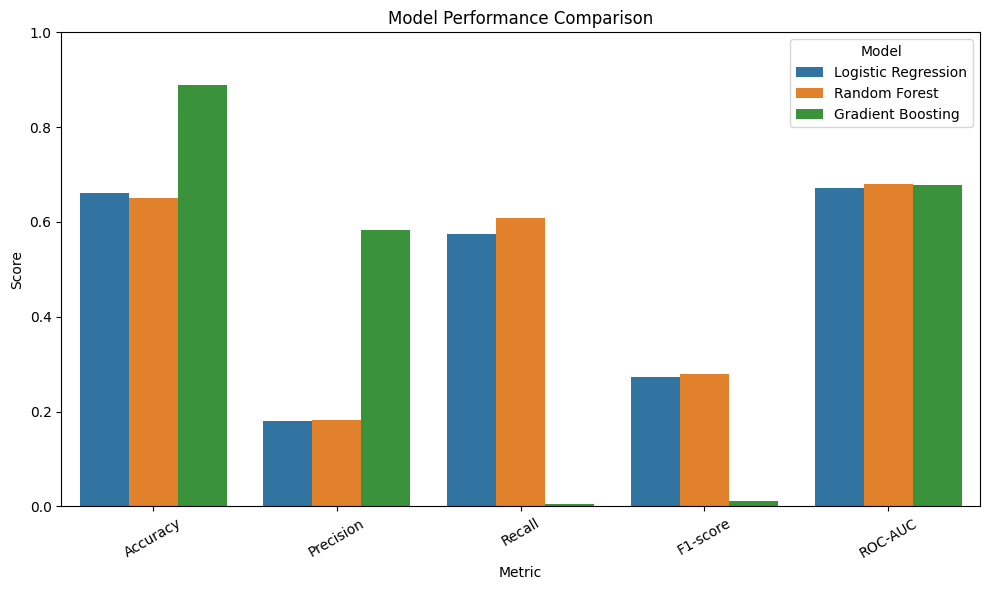

In [12]:
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## ROC Curve Comparison

The ROC curves compare how well each model ranks patients by predicted readmission risk.

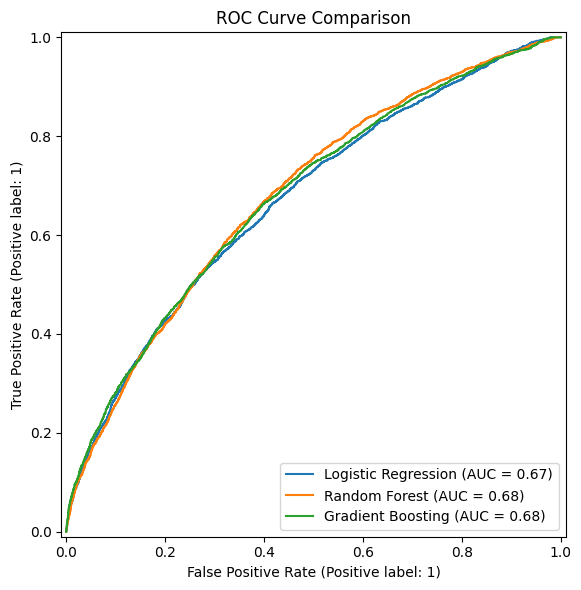

In [13]:
plt.figure(figsize=(8, 6))

for model_name, pipeline in trained_pipelines.items():
    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## Detailed Classification Reports

Classification reports provide class-specific precision, recall, and F1-score.

The minority class, `1`, represents patients readmitted within 30 days.

In [14]:
for model_name, pipeline in trained_pipelines.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18083
           1       0.18      0.57      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354

Random Forest
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18083
           1       0.18      0.61      0.28      2271

    accuracy                           0.65     20354
   macro avg       0.56      0.63      0.52     20354
weighted avg       0.85      0.65      0.71     20354

Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.58      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.74      0.50      0.48     20354
weighted avg       0.8

## Confusion Matrices

Confusion matrices show the number of correct and incorrect predictions for each model.

False negatives are especially important because they represent patients who were actually readmitted within 30 days but were predicted as not readmitted.

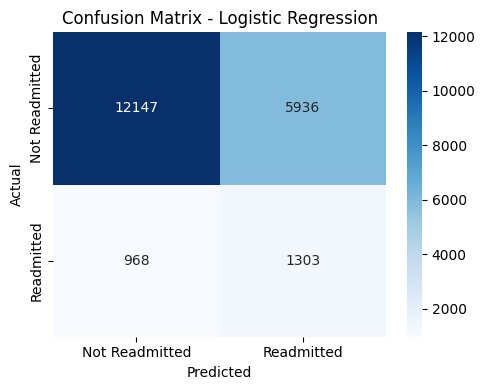

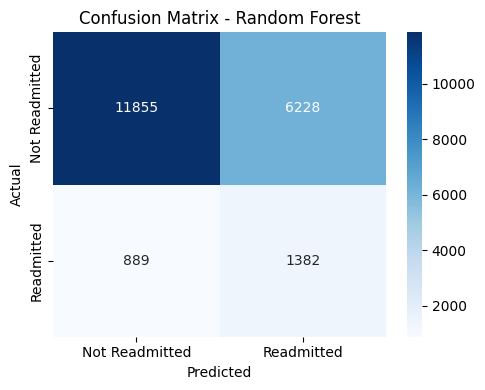

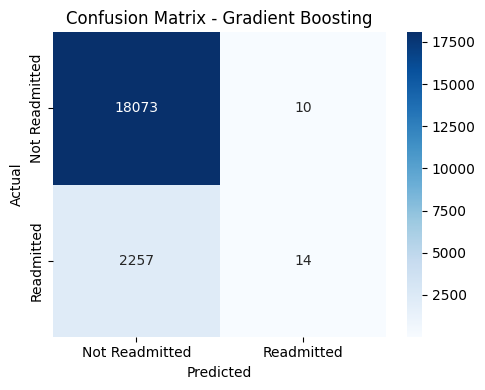

In [15]:
for model_name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Readmitted", "Readmitted"],
        yticklabels=["Not Readmitted", "Readmitted"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## Select Best Model

The best model is selected based primarily on ROC-AUC, while also considering recall.

In this project, ROC-AUC is useful because it evaluates how well the model ranks patients by readmission risk. Recall is important because the healthcare goal is to identify as many truly readmitted patients as possible.

In [16]:
best_model_name = results_df_sorted.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Random Forest


## Model Selection Discussion

Although Gradient Boosting achieved the highest accuracy, it identified very few actual readmission cases and therefore had extremely low recall.

Because the dataset is imbalanced, accuracy alone is not an appropriate model selection criterion.

Random Forest achieved the highest ROC-AUC while also providing the strongest recall and F1-score among the evaluated models.

For this reason, Random Forest was selected as the best-performing model for subsequent threshold tuning and healthcare-focused analysis.

## Save Best Model

The best-performing model pipeline is saved for later threshold tuning and recommendation analysis.

The saved pipeline includes both preprocessing and the trained model.

In [17]:
best_model_path = "../models/best_model_pipeline.pkl"

joblib.dump(best_model, best_model_path)

print(f"Best model saved to: {best_model_path}")

Best model saved to: ../models/best_model_pipeline.pkl


## Model Comparison Interpretation

The model comparison shows that the best-performing model based on ROC-AUC was **[MODEL NAME]**.

Key observations:

- Logistic Regression provided a strong interpretable baseline.
- Random Forest captured nonlinear relationships but should be evaluated carefully for recall.
- Gradient Boosting provided another tree-based comparison and may improve ranking performance.
- Accuracy alone is not enough because the dataset is imbalanced.
- Recall is important because it measures how many actual 30-day readmission cases were correctly identified.

The selected model will be used in the next notebook for threshold tuning and healthcare-focused recommendations.

## Summary

This notebook compared multiple machine learning models for predicting 30-day hospital readmission.

Completed steps:

- Loaded the preprocessed diabetes dataset
- Used the corrected categorical and numerical feature setup
- Applied a stratified train-test split
- Built leakage-safe preprocessing and modeling pipelines
- Trained Logistic Regression, Random Forest, and Gradient Boosting models
- Compared models using accuracy, precision, recall, F1-score, and ROC-AUC
- Reviewed ROC curves, classification reports, and confusion matrices
- Selected the best model based on ROC-AUC and recall considerations
- Saved the best model pipeline for future threshold tuning

The next step is to tune the classification threshold so the model can better support healthcare decision-making, especially when recall is prioritized.